# 记忆的萌芽：RNN与序列建模入门

通过本次任务，你将学会如何使用循环神经网络（RNN）提高情感分析模型的能力，掌握 RNN 的基本原理和实现细节，通过动手实践深入理解其“记忆”机制的运作方式。

## 任务背景

得益于你的努力，无人奶茶店的顾客情感分类问题已得到初步解决。你成功构建了一套基于前馈神经网络的分类流程，能够将杂乱的文本评价转化为结构化的情感标签，显著提升了团队运营分析与反馈处理的效率。

然而，当模型投入真实环境、面对每日持续涌入的海量评价时，一个新的严峻问题逐渐浮现：尽管模型在测试集上表现良好，但其参数量庞大、计算成本高昂，小店现有的资源难以长期支撑。

你意识到，问题的核心可能在于模型架构本身——它的参数量随文本长度急剧增长。这促使你开始思考：是否存在一种具备“记忆”能力的神经网络，能够像人类阅读一样，自然地“记住”已有信息，并将新知识融合到已有认知中，而不是依靠一个持续膨胀的“巨无霸”大脑来强行记忆一切？

现在，就让我们一同踏上探索之旅，揭开神经网络“记忆”背后的奥秘吧！

## 最少必要知识
- 循环神经网络

## 任务鸟瞰

### 任务分析

本次的任务是使用更合适的序列建模模型，解决模型参数量爆炸性增长问题，降低模型训练成本。

![任务鸟瞰](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207073034.png)

传统前馈神经网络通常要求输入数据具有固定长度，而自然语言处理中句子的长度通常是不同的，传统的神经网络无法很好地处理这类变长的序列数据的问题。在上一个实战项目中，为了更顺畅的给大家阐释技术演化的脉络而采用了这种非典型做法。

使用前馈神经网络会把所有的输入拼成一个长向量一股脑的输入到网络中进行处理：

![前馈网络处理文本](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207074325.png)

这样就产生了一个非常大的输入层，更经典的做法是使用循环神经网络（RNN）来处理变长序列数据，每次只让模型处理一个输入。

RNN（循环神经网络）是一种专门处理序列数据的神经网络，引入循环结构允许网络在时间上保留信息，从而更好地处理序列数据。利用 RNN 网络，理论上无论多么长的时序数据，都可以将它的重要信息记录在 RNN 的隐藏状态中。

![RNN](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207074939.png)

使用 RNN 处理文本的流程如下：
- 每次只输入一个字符，并使用 RNN 模型处理该字符，并得到一个隐藏状态。
- 当有新的字符时，基于前一个隐藏状态，处理该字符，并生成新的隐藏状态。
- 循环进行，直到所有输入序列处理完毕，会得到一个最终的隐藏状态，这个隐藏状态就代表了整个文本的语义信息。

![RNN的展开形式](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207074949.png)

### 模型结构

下面我们使用循环神经网络来优化情感分析模型。模型结构如下：

![基于RNN的情感分析模型](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207075745.png)

模型结构中，使用了一个循环神经网络（RNN）代替了前馈神经网络中的输入层和隐藏层，它们的作用都是提取序列的语义特征。

![基于前馈神经网络和RNN的模型对比](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207075805.png)

下面我们进入实战部分，依然沿用 NLP 任务的通用开发流程组织本章内容：定义分词器、数据准备、模型定义、模型训练与模型评估。本次的改进集中在模型结构的改变上，数据准备阶段的流程保持不变，相关代码不在进行赘述。

在正式开始之前，先打印环境的版本号，避免因为环境不同而导致程序不能复现。

### 环境版本

In [1]:
from util import show_version

show_version()

本书愿景：
+------+--------------------------------------------------------+
| Info |                   《动手学人工智能》                   |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 自定义分词器

由于 RNN 模型是按照顺序处理输入的，如果将 `Pad` 放在末尾会引入较大的噪声，所以在对其文本时，将填充位置放在开头，而不是末尾。其余部分代码和前面章节一致，不再进行赘述。

In [2]:
class SimpleTokenizer:
    def __init__(self, pad_at_beginning=False):
        """
        初始化简单分词器
        """
        # 特殊token
        self.pad_token = '[PAD]'
        self.unk_token = '[UNK]'
        self.pad_at_beginning = pad_at_beginning

        # 特殊token ID
        self.pad_token_id = 0
        self.unk_token_id = 1

        # 构建词汇表
        self.vocab = {
            self.pad_token: self.pad_token_id,
            self.unk_token: self.unk_token_id,
        }

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def build_vocab(self, texts):
        """
        根据文本构建词汇表
        """
        for text in texts:
            words = list(text)  # 将每个汉字作为独立token

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = self.vocab_size
                    self.ids_to_tokens[self.vocab_size] = word
                    self.vocab_size += 1

    def build_vocab_from_file(self, file_path):
        """
        从文件中构建词汇表
        """
        texts = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                texts.append(line.strip())

        self.build_vocab(texts)

    def encode(self, text):
        """
        将文本编码为token ids
        """
        tokens = list(text)

        # 转换为IDs
        token_ids = []
        for token in tokens:
            if token in self.vocab:
                token_ids.append(self.vocab[token])
            else:
                token_ids.append(self.unk_token_id)

        return token_ids

    def decode(self, token_ids):
        """
        将token ids解码为文本
        """
        tokens = []
        for token_id in token_ids:
            if token_id in self.ids_to_tokens:
                token = self.ids_to_tokens[token_id]
                # 过滤特殊token（可根据需要调整）
                if token not in [self.pad_token]:
                    tokens.append(token)

        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length, pad_at_beginning=False):
        """
        对序列进行填充或截断
        
        Args:
            sequences: 序列列表
            max_length: 最大长度
            pad_at_beginning: 是否在序列开头填充，默认为False（在末尾填充）
        """
        padded_sequences = []

        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                if pad_at_beginning:
                    # 从开头截断
                    padded_seq = seq[len(seq) - max_length:]
                else:
                    # 从末尾截断
                    padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padding = [self.pad_token_id] * pad_length
                if pad_at_beginning:
                    # 在开头填充
                    padded_seq = padding + seq
                else:
                    # 在末尾填充
                    padded_seq = seq + padding

            padded_sequences.append(padded_seq)

        return padded_sequences

    def __call__(self, texts, max_length=128):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length, self.pad_at_beginning)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

## 准备数据

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://cdn.aibydoing.com/aibydoing/images/aibydoing-pro-icon.svg" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>
```

### 自定义数据转化器

In [3]:
import torch
import torch.nn.functional as F


class TextTransform:
    def __init__(self, tokenizer, max_length=20, vocab_size=None):
        self.tokenizer = tokenizer
        self.max_length = max_length
        # 需要知道词汇表大小来创建 one-hot 向量
        self.vocab_size = vocab_size or tokenizer.vocab_size

    def __call__(self, text):
        # 使用 tokenizer 对文本进行编码，并自动完成截断与填充
        input_ids = self.tokenizer(
            text,
            max_length=self.max_length,  # 最大序列长度
        )

        # 将 input_ids 转换为 one-hot 向量
        # 注意：这里假设 input_ids 是一个列表或者一维张量
        # 如果 input_ids 不是 tensor，则转换为 tensor
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.long)

        # 转换为 one-hot 向量
        one_hot = F.one_hot(input_ids, num_classes=self.vocab_size).float()

        return one_hot

### 自定义文本分类数据集

In [4]:
import torch
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)

        return {
            "input_ids": input_ids,
            "labels": torch.tensor(label, dtype=torch.long)
        }

    @classmethod
    def from_file(cls, file_path, transform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    # 使用制表符分割
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        label = int(parts[0])  # 第一列是标签
                        text = '\t'.join(parts[1:])  # 剩余部分是文本（处理文本中可能包含制表符的情况）
                        texts.append(text)
                        labels.append(label)

        # 创建数据集实例
        return cls(texts, labels, transform)

### 自定义文本分类数据模组

In [5]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, transform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        # 训练、验证和测试数据文件路径
        self.train_data_file = train_data_file  # 训练数据文件路径
        self.val_data_file = val_data_file  # 验证数据文件路径（可选）
        self.test_data_file = test_data_file  # 测试数据文件路径（可选）

        # 数据集实例，初始为None，在setup方法中初始化
        self.test_dataset = None  # 测试数据集
        self.val_dataset = None  # 验证数据集
        self.train_dataset = None  # 训练数据集

        # 批次大小和数据转换器
        self.batch_size = batch_size  # 每个批次的样本数量
        self.transform = transform  # 数据转换器，用于预处理数据

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        # 此方法通常用于下载数据或进行一次性操作
        pass

    def setup(self, stage=None):
        # 根据阶段加载数据集
        # 加载训练数据集
        self.train_dataset = TextClassificationDataset.from_file(self.train_data_file, transform=self.transform)

        # 如果未提供验证数据文件，则使用训练数据集作为验证集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            # 否则加载指定的验证数据集
            self.val_dataset = TextClassificationDataset.from_file(self.val_data_file, transform=self.transform)

        # 如果未提供测试数据文件，则使用验证数据集作为测试集
        if self.test_data_file == "":
            self.test_dataset = self.val_dataset
        else:
            # 否则加载指定的测试数据集
            self.test_dataset = TextClassificationDataset.from_file(self.test_data_file, transform=self.transform)

    def train_dataloader(self):
        # 返回训练数据的DataLoader，启用shuffle以打乱数据顺序
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # 返回验证数据的DataLoader，不打乱数据顺序
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        # 返回测试数据的DataLoader，不打乱数据顺序
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

## 优化情感分析模型

在前面的章节中，我们构建了一个基于前馈神经网络的情感分析模型。该模型虽然结构清晰、易于理解，但在处理顾客评论这样的序列数据时，暴露了其固有的瓶颈。在这里我们我们将使用循环神经网络来重构我们的情感分析模型。模型架构结构如下：

![基于RNN的情感分析模型](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207075745.png)


RNN 层使用一个 RNN 计算单元（RNNCell）循环处理输入序列：

![RNNCell](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260209093022.png)

使用 RNNCell 处理文本的过程如下所示，RNNCell 的权重在不同的时间步中是共享的，因此 RNN 层中的权重参数数量与输入序列的长度无关，只是在训练过程中被不断的更新。

![RNNCell的示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260209093124.png)

下面我们先实现 RNN 计算单元（RNNCell），然后再实现完整的 RNN 层。


### 自定义 RNN 计算单元

RNN计算单元是RNN最基础的构建块，负责定义在单个时间步内，如何结合当前输入 $x_t$ 和上一时刻的隐藏状态 $h_{t-1}$，计算出当前时刻的新隐藏状态 $h_t$。

假设顾客评论是 `珍珠太硬了`，在计算 `珠` 的隐藏特征时，当前的输入是 `珠`，上一时刻的隐藏状态是 $h_{珍}$，经过 RNNCell 计算后，得到 `珠` 的隐藏特征 $h_珠$。

![计算珠的隐藏特征](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260209093704.png)

RNNCell 具体的计算过程如下：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260209093804.png)

我们可以将 RNNCell 进一步抽象成如下计算图：

![RNNCell的计算图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210083338.png)

RNNCell 的计算过程可表示为：$h_t = tanh(W_{xh} * x_t + W_{hh} * h_{t-1} + b_h)$。下面，我们将从零开始构建这个计算单元，以深入理解其内部的数据流动。

In [6]:
import torch
from torch import nn


class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        初始化RNNCell。

        参数:
        - input_size: 输入的特征维度大小
        - hidden_size: 隐藏状态的维度大小
        """

        super(RNNCell, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # 输入到隐藏状态的权重：W_x
        self.weight_xh = nn.Parameter(torch.randn(input_size, hidden_size))

        # 隐藏状态到隐藏状态的权重：W_h
        self.weight_hh = nn.Parameter(torch.randn(hidden_size, hidden_size))

        # 偏置项： b
        self.bias = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, input, hidden_prev):
        """
        前向传播。

        参数:
        - input: 当前时刻的输入 (batch_size, input_size)
        - hidden_prev: 上一时刻的隐藏状态 (batch_size, hidden_size)

        返回:
        - hidden_current: 当前时刻的隐藏状态 (batch_size, hidden_size)
        """
        # 当前时刻的隐藏状态 = 激活函数（前一个时刻的隐藏状态 + 当前输入的信息）
        hidden_current = torch.tanh(
            torch.matmul(hidden_prev, self.weight_hh) +
            torch.matmul(input, self.weight_xh) +
            self.bias
        )

        return hidden_current

`RNNCell` 类是循环神经网络（RNN）的计算单元。它定义了在单个时间步内，如何根据**当前输入**和**上一时刻的内部状态（记忆）**来计算出**当前时刻的新状态**。这个过程模拟了人类在处理信息流时，不断将新信息与已有记忆融合的认知过程。

首先，我们在初始化方法 `__init__`中定义并初始化了该计算单元的所有可学习参数。

初始化方法包含两个输入参数：
- `input_size`: 输入向量 $x_t$ 的维度。在处理文本时，这通常等于词向量的维度（例如 One-Hot 编码后的词汇表大小）。
- `hidden_size`: 隐藏状态向量 $h_t$ 的维度。它决定了 RNNCell “记忆”容量的大小，是一个关键的超参数。更大的 `hidden_size` 意味着模型可以捕捉更复杂、更长期的序列依赖关系，但也会增加计算量。

在初始化方法中，我们创建了三个核心参数：
- `weight_xh` ($W_{xh}$)：形状为 `(input_size, hidden_size)`。它负责对当前输入 `x_t` 进行线性变换，将其信息转换到隐藏状态的空间中。也就是说，它负责提取当前时刻输入中的有效信息。
- `weight_hh` ($W_{hh}$)：形状为 `(hidden_size, hidden_size)`。这是实现“循环”或“记忆”功能的关键。它作用于上一时刻的隐藏状态 $h_{t-1}$，决定了过去的信息如何影响当前的状态。
- `bias` ($b_h$)：形状为 `(hidden_size,)`。偏置项为计算增加了一个偏移量，使模型更具灵活性。

RNNCell 这些参数在时间维度上是**共享**的。无论序列有多长，处理第 `1` 个时间步和第 `100` 个时间步使用的都是同一组 $W_{xh}$, $W_{hh}$, $b_h$。这种参数共享机制是 RNN 能够处理任意长度序列、且模型参数量固定的根本原因。

然后，在前向传播方法 `forward` 中实现在时刻 `t` 的计算过程。前向传播方法也有两个参数：
- `input` ($x_t$)：当前时间步的输入，形状为 `(batch_size, input_size)`。
- `hidden_prev` ($h_{t-1}$)：上一时间步的隐藏状态，形状为 `(batch_size, hidden_size)`。在序列开始时，通常初始化为全零向量。

前向传播的计算严格遵循了基础RNN的公式，计算过程可以分为三步：
1. **信息融合**：
    - 使用 `torch.matmul(hidden_prev, self.weight_hh)` 从过去的记忆 $h_{t-1}$ 中提取有用信息；
    - 使用 `torch.matmul(input, self.weight_xh)` 从当前的新输入 $x_t$ 中提取有用信息；
    - 两者相加，实现了将历史信息与当前输入信息相互融合。
2. **添加偏置**：加上偏置项 `self.bias`。
3. **非线性激活**：使用 `tanh()` 作为激活函数。`tanh` 函数将结果压缩到 `(-1, 1)` 的范围内，一方面有助于控制数值的尺度，另一方面其以零为中心的特性有利于梯度的流动。

最终，前向传播返回 `hidden_current`($h_t$)，它既作为当前时间步的输出（可用于预测），也作为下一个时间步的输入（即记忆），传递给下一个时刻的`RNNCell`，从而在时间线上形成信息的循环与传递。

### 自定义 RNN 层

我们实现了基础的 RNN 计算单元（RNNCell）。现在将基于 RNNCell 构建完整的 RNN 层，使其能够循环的处理序列数据。

同样的，我们先来回顾一下 RNN 层的展开视图：

![RNNCell的示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260209093124.png)


`RNN层` 的主要功能是将一个 `RNN计算单元` 在时间维度上循环展开，形成一个能够处理完整序列的神经网络层。所以 RNN 层需要：
1. **管理整个序列的时间步处理；**
2. **维护隐藏状态在整个序列中的传递；**
3. **处理批量数据并返回所有时间步的输出；**
 
我们将自定义 RNN 类并实现前向传播逻辑：接收一个完整的序列（如一个句子的所有词向量），遍历每一个位置依次调用 `RNNCell` 计算当前位置对应的隐藏状态，最后一个时间步的隐藏状态浓缩了整个序列的信息。

In [7]:
from torch import nn


class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        初始化RNN层。

        参数:
        - input_size: 输入的特征维度大小
        - hidden_size: 隐藏状态的维度大小
        """
        super(RNN, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        self.rnn_cell = RNNCell(input_size, hidden_size)

    def forward(self, inputs, hidden=None):
        """
        前向计算

        参数:
        - inputs: 输入序列 (batch_size, seq_len, input_size)
        - hidden: 初始隐藏状态 (batch_size, hidden_size)，默认为零初始化

        返回:
        - outputs: 所有时间步的隐藏状态 (batch_size, seq_len, hidden_size)
        """
        batch_size, seq_len, _ = inputs.size()

        if hidden is None:
            hidden = torch.zeros(batch_size, self.hidden_size).type_as(inputs)

        outputs = []

        # 遍历时间步，计算每一个时间步的隐藏状态
        for t in range(seq_len):
            hidden = self.rnn_cell(inputs[:, t, :], hidden)  # 按时间步处理
            outputs.append(hidden)

        # 沿着seq_len维度堆叠，将list转化为tensor (batch_size, seq_len, hidden_size)
        outputs = torch.stack(outputs, dim=1)
        return outputs

循环神经网络层的核心在于其能够处理序列数据并维持一个内部状态（隐藏状态），该状态承载了序列的历史信息。一个完整的 RNN 层核心功能可总结为以下两部分：
1. **初始化方法`__init__`**
在初始化方法中，我们会创建一个 `RNNCell` 实例，并在所有时间步中重复调用。
2. **前向传播方法 `forward`**
`forward`方法是 RNN 层功能的核心体现，它负责将输入序列在时间维度上进行计算。其标准执行流程如下：
    - **解析输入维度**：解析输入张量的形状，获取批次大小（`batch_size`）和序列长度（`seq_len`）。
    - **初始化隐藏状态**：根据是否提供了初始状态，来初始化第一个时间步的隐藏状态`h_0`。通常将其初始化为全零张量。
    - **时间步循环迭代**：然后，循环计算每一个时间步（位置）的隐藏状态。
    - **收集与堆叠输出**：在循环过程中，每个时间步的输出被收集起来。循环结束后，将每个时间步的隐藏状态合并成形状为 `(batch_size, seq_len, hidden_size)` 的张量。其中，最后一个时间步的隐藏状态 $h_t$ 就代表了整个序列的隐藏特征。

从理论上来说，通过这种设计，在不改变参数量的情况下，RNN 层就能轻松地处理任意长度的序列数据。

### 情感分析模型的代码重构

使用 RNN 来重构我们的情感分类模型。模型结构如下：

![基于RNN的情感分析模型](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260207075745.png)

其中：`OneHot` 编码操作已在数据预处理步骤中完成，`softmax` 只在推理阶段使用，所以在 `__init__()` 中无需添加它们。

情感分析模型前向传播计算如下：

![前向传播计算示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210111331.png)

RNN 层输出的最后一个时间步代表整个序列的特征，所以只取最后一个时间步的隐藏状态作为输出层 `output_layer` 的输入。


In [8]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, input_size=10, hidden_size=128, num_classes=2, learning_rate=0.01):
        super(TextClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 🌟改进点：定义网络层
        self.rnn = RNN(input_size, hidden_size)  # RNN层
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.Tensor(32, 30, input_size)

        # 标签id到标签的映射，用于预测解码
        self.label_map = None

    def forward(self, x):
        """前向传播"""
        # 通过RNN层处理输入序列
        outputs = self.rnn(x)  # outputs形状: (batch_size, seq_len, hidden_size)

        # 取最后一个时间步的输出作为特征
        last_output = outputs[:, -1, :]  # 形状: (batch_size, hidden_size)

        # 将最后一个时间步的特征输入到输出层
        out = self.output_layer(last_output)  # 形状: (batch_size, num_classes)

        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]
        target_ids = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, label_map=None):
        """根据数据集设置标签映射"""
        self.label_map = label_map

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 【新增】判断输入类型并处理
        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.label_map[label_id] for label_id in label_ids]

本章模型的核心改进体现在前向传播（forward）方法中。具体计算流程如下：
- 输入序列通过RNN层处理，得到所有时间步的输出。
- 取最后一个时间步的输出作为整个序列的特征表示。
- 将该特征输入到输出层，生成最终的情感倾向分数。

### 情感分析模型的详细信息

初始化模型并查看详细的摘要信息。

In [9]:
# 导入模型摘要工具，用于查看模型的结构和参数信息
from lightning.pytorch.utilities.model_summary import ModelSummary

# 指定训练数据文件路径
file_path = "./dataset/comments_train.txt"

# 初始化分词器并从训练数据文件中构建词汇表
tokenizer = SimpleTokenizer(pad_at_beginning=True)
tokenizer.build_vocab_from_file(file_path)

# 初始化情感分类模型，设置输入大小为词汇表大小，隐藏层大小为128，分类数为2（正面/负面），学习率为0.001
model = TextClassifier(input_size=tokenizer.vocab_size, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 生成模型摘要，max_depth=-1表示显示所有层级的详细信息
summary = ModelSummary(model, max_depth=-1)

# 打印模型摘要信息
print(summary)


  | Name         | Type    | Params | Mode  | FLOPs  | In sizes                | Out sizes    
----------------------------------------------------------------------------------------------------
0 | rnn          | RNN     | 237 K  | train | 455 M  | [32, 30, 1725]          | [32, 30, 128]
1 | rnn.rnn_cell | RNNCell | 237 K  | train | 455 M  | [[32, 1725], [32, 128]] | [32, 128]    
2 | output_layer | Linear  | 258    | train | 16.4 K | [32, 128]               | [32, 2]      
----------------------------------------------------------------------------------------------------
237 K     Trainable params
0         Non-trainable params
237 K     Total params
0.950     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
455 M     Total Flops


从模型摘要信息中可以看出，`TextClassifier` 模型由一个 RNN 层和一个输出层构成。其中，RNN 层的参数量仅为 `237 K`（千参数）。作为对比，前一章使用的前馈神经网络模型参数量高达 `6.6 M`（百万参数），使用 RNN 显著缓解了参数量膨胀的问题。

![参数量对比](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210153017.png)

## 模型训练与评估
### 初始化模型和训练器

In [10]:
# 超参配置
max_length = 30
batch_size = 32

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(pad_at_beginning=True)
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")

# 2️⃣ 创建 TextTransform 实例
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 创建 DataModule 实例
datamodule = TextDataModule(batch_size=batch_size, transform=transform, train_data_file="./dataset/comments_train.txt")

# 4️⃣ 创建 TextClassifier 模型实例
model = TextClassifier(input_size=tokenizer.vocab_size, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 5️⃣ 创建PyTorch Lightning训练器，设置训练参数：
# - max_epochs=12: 最大训练轮数为12
# - log_every_n_steps=3: 每3个步骤记录一次日志
# - check_val_every_n_epoch=3: 每3个epoch进行一次验证
# - enable_progress_bar=False: 不显示进度条
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0,
                    enable_progress_bar=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


### 训练前评估

训练前评估为模型性能建立初始基准。

In [11]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1332.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.4882698059082031     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1332.0,
  'val_overall_acc': 0.4882698059082031}]

模型在训练之前的预测准确率仅为 `48.82%`，该数值与随机猜测的水平基本一致，这表明模型在未经训练时，不具备实质的预测能力。

### 训练模型

调用 `trainer.fit()` 训练 12 个轮次。

In [12]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type   ┃ Params ┃ Mode  ┃  FLOPs ┃       In sizes ┃     Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0 │ rnn          │ RNN    │  237 K │ train │  455 M │ [32, 30, 1725] │ [32, 30, 128] │
│ 1 │ output_layer │ Linear │    258 │ train │ 16.4 K │      [32, 128] │       [32, 2] │
└───┴──────────────┴────────┴────────┴───────┴────────┴────────────────┴───────────────┘

Trainable params: 237 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 237 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 455 M

`Trainer.fit` stopped: `max_epochs=12` reached.


#### 训练过程可视化

绘制训练过程中损失值的曲线，更直观地观察模型性能变化的趋势。

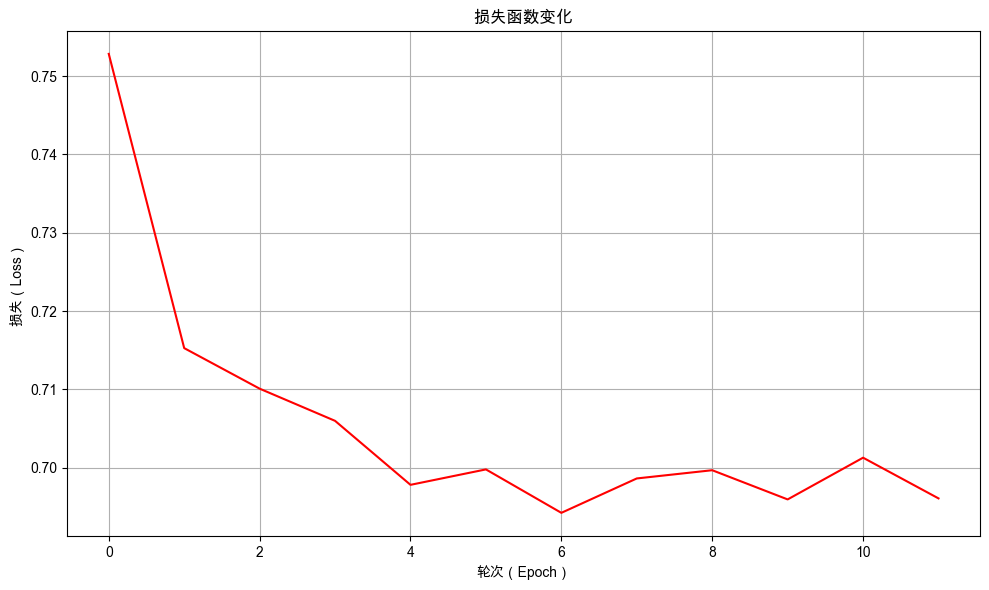

In [13]:
from util import plot_training_loss

plot_training_loss(model.train_epoch_losses)

从图中可以看出随着训练的进行，损失值不断下降，表示模型性能在不断提高。

#### 查看模型评估记录

查看训练过程中的评估结果，观察模型在验证集上的表现。

In [14]:
from util import show_table

show_table(model.eval_accuracies)

,epoch,总样本数,正确样本数,准确率
0,0,2728,1399,0.5128
1,1,2728,1351,0.4952
2,2,2728,1362,0.4993
3,3,2728,1373,0.5033
4,4,2728,1454,0.5330
5,5,2728,1432,0.5249
6,6,2728,1407,0.5158
7,7,2728,1392,0.5103
8,8,2728,1344,0.4927
9,9,2728,1365,0.5004


在训练的过程中，模型准确率始终徘徊在 `50%` 左右，这表明其未能有效学习。接下来，我们将进一步评估以确认这一结论。

### 训练后评估

In [15]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1468.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.5381231904029846     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1468.0,
  'val_overall_acc': 0.5381231904029846}]

模型在训练之后的准确率只有 `53.81%`，本次训练好像确实失败了。

## 使用模型进行预测

在模型训练完成后，需要评估模型的泛化能力。我们准备了一组包含不同长度（短、中、长）且情感倾向明确的评论文本，并调用模型的 `predict` 方法进行推理预测，直观地观察模型在实际应用中的表现。

In [21]:
model.setup_label_map(label_map={0: "负面", 1: "正面"})

from util import print_classification_results

# 1. 准备需要预测的文本（长短不一）
new_texts = [
    # 短文本
    "非常好",
    "质量差",
    "推荐购买",
    "不建议买",

    # 中等长度文本
    "这个产品还不错",
    "物流速度太慢了",
    "性价比很高值得推荐",

    # 长文本
    "包装很精美，产品和描述一致，非常满意这次购物体验",
    "卖家服务态度不好，发货速度慢，产品质量也不如预期",
    "虽然价格有点贵，但是品质确实不错，使用效果很满意"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 1, 0, 1]

# 2. 使用与训练时统一的 transform 方法对文本进行处理
input_ids = []
for text in new_texts:
    # 使用训练时相同的 transform 方法
    transformed = transform(text)
    input_ids.append(transformed)

# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4. 输出预测结果
print_classification_results(new_texts, true_labels, predictions, probabilities, model.label_map)

[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
🎯 分类预测结果 (准确率: 4/10 = 40.00%)：
+--------------------------------------------------+----------+----------+----------+------+
|                       输入                       | 真实标签 | 预测标签 | 最高概率 | 标记 |
+--------------------------------------------------+----------+----------+----------+------+
|                      非常好                      |   正面   |   负面   |  0.6046  |  ☒   |
|                      质量差                      |   负面   |   负面   |  0.5396  |  ☑   |
|                     推荐购买                     |   正面   |   负面   |  0.6010  |  ☒   |
|                     不建议买                     |   负面   |   负面   |  0.5372  |  ☑   |
|                  这个产品还不错                  |   正面   |   负面   |  0.5305  |  ☒   |
|                  物流速度太慢了                  |   负面   |   负面   |  0.6324  |  ☑   |
|                性价比很高值得推荐                | 

本次预测只有 `40%` 的正确率，又一次表明咱们的学习训练失败了。为什么会这样呢？

## 问题分析

:::{admonition} 🤔 OneHot 编码结合 RNN 为何会训练失败？
:class: note

将 One-Hot 编码直接用于RNN进行文本分类，常导致模型训练失败或效果不佳。这并非模型能力不足，而是**数据表示与模型架构之间存在根本性错配**。其核心原因在于，One-Hot 向量本身是高维、稀疏、且语义孤立的，这使得 RNN 难以从中捕捉有意义的语义模式和上下文关系进行有效学习。

更深层次的问题源于 RNN 的**权重共享机制**与 One-Hot 编码的**稀疏性**之间的冲突。RNN在每个时间步使用相同的权重矩阵处理输入。当输入是 One-Hot 向量时，每个时间步仅有一个维度为 1，其余全为 0。**在每个时间步，输入向量 $x_{t}$ 与 $W_{xh}$ 矩阵做点积，实质上只是从 $W_{xh}$ 中提取出与当前词对应的一行权重，而矩阵的其他行在该时间步的贡献为零。**

![OneHot与RNN错配](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260210133723.png)

这种机制直接导致了“**梯度更新稀疏**”问题。在反“学不会”或收敛缓慢向传播过程中，只有当前时间步所对应词汇的那一行权重会获得梯度更新，而权重矩阵的其余部分在该时间步的梯度为零。当词汇表很大且语料分布不均时，许多低频词的对应权重行在单次训练迭代中几乎得不到更新机会，这使得模型的权重难以学习到有用的信息，最终导致模型训练失败。

当词汇表很大时，这种情况会更加严重。因此，在现代自然语言处理中，会使用更好的词嵌入方式将 Token 映射到低维、稠密且蕴含语义的连续向量空间上，这才是 RNN 及其变体（如LSTM、GRU）能够有效处理文本数据的关键前提。
:::

## 本章小结

本章系统阐述了循环神经网络的基本原理与实现方法。通过引入循环结构，`RNN` 能够将历史信息传递至当前时刻，从而有效捕捉序列数据中的时序依赖关系。`RNN` 通过参数共享，成功解决了前馈神经网络在处理时序数据时参数数量激增的问题。然而，直接将高维、稀疏的 `One-Hot` 词嵌入输入 `RNN` 进行文本分类，却会导致训练失败。下一章，我们将使用稠密的词嵌入来解决这个问题。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://cdn.aibydoing.com/aibydoing/images/aibydoing-pro-icon.svg" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```